# эксперимент: более глубокая модель

та же генеративная модель, что в `03_generative_transformer_final`, но 4 слоя вместо 2, dropout 0.2, AdamW с weight decay 0.01 (без него у эмбеддингов), warmup 3 эпохи + cosine decay

## imports & install

In [ ]:
import numpy as np
import pandas as pd
import math
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pad_sequence
from collections import Counter
import matplotlib.pyplot as plt

## data

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
base_path = '/content/drive/MyDrive/pet_proj_recomendashki'
semantic_ids = np.load(f'{base_path}/data/semantic_ids.npy')
seq_df = pd.read_parquet(f'{base_path}/data/sequences_final')

print(semantic_ids.shape)
seq_df.head(2)

(26354, 3)


,user_id,item_seq,seq_len,item_seq_idx,train_hist,val,test,test_hist
0,AE2252DKW4XJIZP5QPFMQVJBVRTA,"[B0050SX4CI, B002ORTCAQ, B0090ECASW, B004OYV7Z...",11,"[16045, 2967, 10768, 11369, 22231, 13083, 2403...","[16045, 2967, 10768, 11369, 22231, 13083, 2403...",10554,21092,"[16045, 2967, 10768, 11369, 22231, 13083, 2403..."
1,AE22EOGVXOMYJ2QFJSYLWVBVAOAA,"[B008GEH9HO, B00CWV550U, B00J7N6C26, B07X6481D...",6,"[22999, 25270, 23345, 14220, 15609, 8219]","[22999, 25270, 23345, 14220]",15609,8219,"[22999, 25270, 23345, 14220, 15609]"


In [ ]:
def items_to_semantic(item_seq, semantic_ids):
    codes = semantic_ids[item_seq]
    return codes.flatten().tolist()

In [ ]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

cuda


## dataset

In [ ]:
class SemanticSeqDataset(Dataset):
    def __init__(self, sequences):
        self.sequences = sequences

    def __len__(self):
        return len(self.sequences)

    def __getitem__(self, idx):
        seq = self.sequences[idx]
        return torch.tensor(seq, dtype=torch.long)

In [ ]:
PAD_TOKEN = 256
vocab_size_per_level = 257

In [ ]:
def collate_fn(batch):
    padded = pad_sequence(batch, batch_first=True, padding_value=PAD_TOKEN)
    return padded

In [ ]:
MAX_SEQ_LEN = 128
MAX_ITEMS = MAX_SEQ_LEN // 3

In [ ]:
def truncate_and_convert(item_id_list, semantic_ids, max_items=MAX_ITEMS):
    if len(item_id_list) > max_items:
        item_id_list = item_id_list[-max_items:]
    return items_to_semantic(item_id_list, semantic_ids)

In [ ]:
seq_df['train_semantic'] = seq_df['train_hist'].apply(lambda x: truncate_and_convert(x, semantic_ids))
seq_df['test_hist_semantic'] = seq_df['test_hist'].apply(lambda x: truncate_and_convert(x, semantic_ids))

In [ ]:
dataset = SemanticSeqDataset(seq_df['train_semantic'].tolist())
dataloader = DataLoader(dataset, batch_size=64, shuffle=True, collate_fn=collate_fn)

## архитектура

In [ ]:
class RotaryPositionEmbedding(nn.Module):
    def __init__(self, dim, max_seq_len=MAX_SEQ_LEN, base=10 ** 4):
        super().__init__()
        positions = torch.arange(max_seq_len)
        inv_freq = 1.0 / (base ** (torch.arange(0, dim, 2).float() / dim))
        angles = torch.outer(positions.float(), inv_freq)
        self.register_buffer('cos_cached', angles.cos())
        self.register_buffer('sin_cached', angles.sin())

    def forward(self, x):
        # batch, num_heads, seq_len, head_dim
        seq_len = x.shape[2]
        x1 = x[..., 0::2]
        x2 = x[..., 1::2]
        cos = self.cos_cached[:seq_len, :]
        sin = self.sin_cached[:seq_len, :]

        rotated_x1 = x1 * cos - x2 * sin
        rotated_x2 = x1 * sin + x2 * cos

        out = torch.stack([rotated_x1, rotated_x2], dim=-1)
        out = out.flatten(-2)

        return out

In [ ]:
def build_attention_mask(tokens, pad_token, num_heads):
    # batch, seq_len
    batch, seq_len = tokens.shape
    device = tokens.device

    causal_mask = torch.triu(torch.ones(seq_len, seq_len, dtype=torch.bool, device=device), diagonal=1)
    causal_mask = causal_mask.unsqueeze(0).unsqueeze(0)

    padding_mask = (tokens == pad_token)
    padding_mask = padding_mask.unsqueeze(1).unsqueeze(1)

    combined_mask = causal_mask | padding_mask

    return combined_mask

In [ ]:
class MultiHeadAttention(nn.Module):
    def __init__(self, d_model, n_heads, max_seq_len=MAX_SEQ_LEN):
        super().__init__()
        self.d_model = d_model
        self.n_heads = n_heads
        self.head_dim = d_model // n_heads

        self.W_q = nn.Linear(d_model, d_model)
        self.W_k = nn.Linear(d_model, d_model)
        self.W_v = nn.Linear(d_model, d_model)
        self.head_agg = nn.Linear(d_model, d_model)
        self.rope = RotaryPositionEmbedding(dim=self.head_dim, max_seq_len=max_seq_len)

    def forward(self, x, attn_mask):
        # batch, seq_len, d_model
        batch, seq_len, _ = x.shape
        Q = self.W_q(x)
        K = self.W_k(x)
        V = self.W_v(x)

        Q_multi = Q.view(batch, seq_len, self.n_heads, self.head_dim).transpose(1, 2)
        K_multi = K.view(batch, seq_len, self.n_heads, self.head_dim).transpose(1, 2)
        V_multi = V.view(batch, seq_len, self.n_heads, self.head_dim).transpose(1, 2)

        Q_rope = self.rope(Q_multi)
        K_rope = self.rope(K_multi)

        pre_softmax = Q_rope @ K_rope.transpose(-2, -1) / math.sqrt(self.head_dim)

        pre_softmax = pre_softmax.masked_fill(attn_mask, float('-inf'))

        atttention = torch.softmax(pre_softmax, dim=-1) @ V_multi
        atttention = atttention.transpose(1, 2).contiguous().view(batch, seq_len, self.d_model)

        out = self.head_agg(atttention)

        return out

In [ ]:
class FeedForward(nn.Module):
    def __init__(self, d_model, d_ff=None, dropout=0.1):
        super().__init__()
        d_ff = d_ff or d_model * 4
        self.net = nn.Sequential(
            nn.Linear(d_model, d_ff),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(d_ff, d_model)
        )

    def forward(self, x):
        return self.net(x)

In [ ]:
class DecoderBlock(nn.Module):
    def __init__(self, d_model, n_heads, max_seq_len=MAX_SEQ_LEN, dropout=0.1):
        super().__init__()
        self.norm1 = nn.LayerNorm(d_model)
        self.attention = MultiHeadAttention(d_model, n_heads, max_seq_len)
        self.dropout = nn.Dropout(dropout)
        self.norm2 = nn.LayerNorm(d_model)
        self.ffn = FeedForward(d_model, dropout=dropout)

    def forward(self, x, attn_mask):
        atten_out = self.attention(self.norm1(x), attn_mask=attn_mask)
        x = x + self.dropout(atten_out)

        ffn_out = self.ffn(self.norm2(x))
        x = x + self.dropout(ffn_out)

        return x

In [ ]:
class MultiLevelEmbedding(nn.Module):
    def __init__(self, num_codes, n_levels, d_model, pad_token=None):
        super().__init__()
        self.n_levels = n_levels
        vocab_size = num_codes + 1
        self.embeddings = nn.ModuleList([
            nn.Embedding(vocab_size, d_model) for i in range(n_levels)
        ])

    def forward(self, tokens):
        batch, seq_len = tokens.shape
        num_items = seq_len // self.n_levels

        tokens_reshaped = tokens.view(batch, num_items, self.n_levels)
        level_embeddings = []
        for level in range(self.n_levels):
            level_tokens = tokens_reshaped[:, :, level]
            level_embeddings.append(self.embeddings[level](level_tokens))

        out = torch.stack(level_embeddings, dim=2)
        out = out.view(batch, seq_len, -1)
        return out

In [ ]:
class DecoderOnlyTransformer(nn.Module):
    def __init__(self, num_codes, n_levels, d_model, n_heads, n_layers,
                 max_seq_len=MAX_SEQ_LEN, pad_token=PAD_TOKEN, dropout=0):
        super().__init__()
        self.n_levels = n_levels
        self.pad_token = pad_token
        self.embeddings = MultiLevelEmbedding(num_codes, n_levels, d_model, pad_token)

        self.blocks = nn.ModuleList([
            DecoderBlock(d_model, n_heads, max_seq_len, dropout) for i in range(n_layers)
        ])
        self.final_norm = nn.LayerNorm(d_model)
        self.out_heads = nn.ModuleList([
            nn.Linear(d_model, num_codes + 1) for i in range(n_levels)
        ])

    def forward(self, tokens, attn_mask):
        x = self.embeddings(tokens)
        for block in self.blocks:
            x = block(x, attn_mask=attn_mask)
        x = self.final_norm(x)

        batch, seq_len, d_model = x.shape
        level_ids = (torch.arange(seq_len, device=x.device) + 1) % self.n_levels

        logits = torch.zeros(batch, seq_len, self.out_heads[0].out_features, device=x.device)
        for level in range(self.n_levels):
            mask = (level_ids == level)
            logits[:, mask, :] = self.out_heads[level](x[:, mask, :])

        return logits

## beam search

In [ ]:
def prepare_history_for_generation(history_tokens, max_seq_len, num_levels=3, reserve=3):
    max_history_len = max_seq_len - reserve
    max_history_items_len = (max_history_len // num_levels) * num_levels
    if len(history_tokens) > max_history_items_len:
        history_tokens = history_tokens[-max_history_items_len:]
    return history_tokens

In [ ]:
def beam_search_generate(model, history_tokens, trie, num_levels=3, k=10, pad_token=256, device='cpu'):
    model.eval()
    beams = [([], 0.0)]

    with torch.no_grad():
        for level in range(num_levels):
            batch_seqs = []
            real_positions = []
            for prefix, score in beams:
                full_seq = history_tokens + prefix
                remainder = len(full_seq) % 3
                real_pos = len(full_seq) - 1
                if remainder != 0:
                    full_seq = full_seq + [0] * (3 - remainder)
                batch_seqs.append(full_seq)
                real_positions.append(real_pos)

            max_len = max(len(s) for s in batch_seqs)
            padded_batch = [s + [pad_token] * (max_len - len(s)) for s in batch_seqs]
            input_tensor = torch.tensor(padded_batch, device=device)

            attn_mask = build_attention_mask(input_tensor, pad_token, model.blocks[0].attention.n_heads)
            logits = model(input_tensor, attn_mask=attn_mask)

            candidates = []
            for i, (prefix, score) in enumerate(beams):
                next_logits_i = logits[i, real_positions[i], :]

                valid_codes = trie.valid_next_codes(prefix)
                if len(valid_codes) == 0:
                    continue
                mask = torch.full_like(next_logits_i, float('-inf'))
                mask[valid_codes] = 0
                masked_logits = next_logits_i + mask
                log_probs = F.log_softmax(masked_logits, dim=-1)

                topk_log_probs, topk_codes = torch.topk(log_probs, k=min(k, len(valid_codes)))
                for code, log_p in zip(topk_codes.tolist(), topk_log_probs.tolist()):
                    candidates.append((prefix + [code], score + log_p))

            candidates.sort(key=lambda x: x[1], reverse=True)
            beams = candidates[:k]

    return beams

In [ ]:
class SemanticIDTrie:
    def __init__(self, all_semantic_ids):
        self.trie = {}
        self.id_to_item = {}
        for item_id, ids in enumerate(all_semantic_ids):
            ids_tuple = tuple(ids.tolist())
            self.id_to_item[ids_tuple] = item_id
            node = self.trie
            for code in ids_tuple:
                node = node.setdefault(code, {})

    def valid_next_codes(self, prefix):
        node = self.trie
        for code in prefix:
            node = node.get(code, {})
        return list(node.keys())

    def get_item_id(self, semantic_id_tuple):
        return self.id_to_item.get(semantic_id_tuple, None)

In [ ]:
trie = SemanticIDTrie(semantic_ids)

## metrics

Recall@k и NDCG@k по результатам beam search. ширина луча по умолчанию равна максимальному k

In [ ]:
def get_logits_at_position(model, seq, real_pos, device):
    remainder = len(seq) % 3
    padded_seq = seq + [0] * (3 - remainder) if remainder != 0 else seq
    seq_tensor = torch.tensor([padded_seq], device=device)
    attn_mask = build_attention_mask(seq_tensor, PAD_TOKEN, model.blocks[0].attention.n_heads)
    logits = model(seq_tensor, attn_mask=attn_mask)
    return logits[0, real_pos, :]


def compute_metrics(model, seq_df, trie, k_list=[5, 10, 50, 100], pad_token=PAD_TOKEN,
                    device='cpu', max_seq_len=MAX_SEQ_LEN, hist_col='test_hist_semantic',
                    target_col='test', beam_width=None):
    model.eval()
    recalls = {k: [] for k in k_list}
    ndcgs = {k: [] for k in k_list}
    max_k = max(k_list)

    for _, row in seq_df.iterrows():
        history = prepare_history_for_generation(row[hist_col], max_seq_len, num_levels=3, reserve=3)
        true_item_id = row[target_col]

        beams = beam_search_generate(model, history, trie, num_levels=3, k=beam_width or max_k,
                                     pad_token=pad_token, device=device)
        predicted_ids = [trie.get_item_id(tuple(seq)) for seq, score in beams]

        for k in k_list:
            top_k_preds = predicted_ids[:k]
            hit = true_item_id in top_k_preds
            recalls[k].append(1.0 if hit else 0.0)
            if hit:
                rank = top_k_preds.index(true_item_id) + 1
                ndcgs[k].append(1.0 / np.log2(rank + 1))
            else:
                ndcgs[k].append(0.0)

    results = {}
    for k in k_list:
        results[f'Recall@{k}'] = np.mean(recalls[k])
        results[f'NDCG@{k}'] = np.mean(ndcgs[k])
    return results

## baseline

основная модель (эпоха 50) на той же валидационной выборке

In [ ]:
checkpoint_dir = f'{base_path}/checkpoints'
val_mid = seq_df.sample(n=2000, random_state=2)

ck = torch.load(f'{checkpoint_dir}/transformer_fixed_epoch50.pt', map_location=device, weights_only=False)
model = DecoderOnlyTransformer(**ck['config']).to(device)
model.load_state_dict(ck['model_state_dict'])
base_val = compute_metrics(model, val_mid, trie, k_list=[10, 100], device=device,
                           hist_col='train_semantic', target_col='val', beam_width=30)
print('основная модель, эпоха 50:', base_val)

основная модель, эпоха 50: {'Recall@10': np.float64(0.0735), 'NDCG@10': np.float64(0.041525050567145554), 'Recall@100': np.float64(0.122), 'NDCG@100': np.float64(0.05312040328302146)}


## обучение

In [ ]:
config_big = {
    'num_codes': 256, 'n_levels': 3, 'd_model': 256, 'n_heads': 4, 'n_layers': 4,
    'max_seq_len': MAX_SEQ_LEN, 'pad_token': PAD_TOKEN, 'dropout': 0.2,
}
max_epochs = 60
warmup_epochs = 3

torch.manual_seed(42)
model_big = DecoderOnlyTransformer(**config_big).to(device)

embedding_params = list(model_big.embeddings.parameters())
other_params = [p for n, p in model_big.named_parameters() if not n.startswith('embeddings')]
optimizer_big = torch.optim.AdamW([
    {'params': embedding_params, 'lr': 3e-3, 'weight_decay': 0.0},
    {'params': other_params, 'lr': 1e-3, 'weight_decay': 0.01},
])

total_steps = max_epochs * len(dataloader)
warmup_steps = warmup_epochs * len(dataloader)

def lr_lambda(step):
    if step < warmup_steps:
        return (step + 1) / warmup_steps
    progress = (step - warmup_steps) / max(1, total_steps - warmup_steps)
    return 0.5 * (1 + math.cos(math.pi * progress))

scheduler_big = torch.optim.lr_scheduler.LambdaLR(optimizer_big, lr_lambda)
hist_big = {'loss': [], 'val_epoch': [], 'val_recall10': []}
best_val_big, best_epoch_big = -1.0, None

In [ ]:
while len(hist_big['loss']) < max_epochs:
    model_big.train()
    epoch_loss = 0
    n_batch = 0

    for batch in dataloader:
        n_batch += 1
        batch = batch.to(device)
        input_seq = batch
        target_seq = F.pad(batch[:, 1:], (0, 1), value=PAD_TOKEN)
        attn_mask = build_attention_mask(input_seq, PAD_TOKEN, model_big.blocks[0].attention.n_heads)

        optimizer_big.zero_grad()
        logits = model_big(input_seq, attn_mask=attn_mask)
        loss = F.cross_entropy(
            logits.reshape(-1, logits.shape[-1]),
            target_seq.reshape(-1),
            ignore_index=PAD_TOKEN
        )
        loss.backward()
        optimizer_big.step()
        scheduler_big.step()
        epoch_loss += loss.item()

    avg_loss = epoch_loss / n_batch
    hist_big['loss'].append(avg_loss)
    global_epoch = len(hist_big['loss'])
    print(f"epoch {global_epoch} | loss: {round(avg_loss, 4)} | lr: {scheduler_big.get_last_lr()[1]:.2e}")

    if global_epoch % 10 == 0:
        val_r10 = float(compute_metrics(model_big, val_mid, trie, k_list=[10], device=device,
                                        hist_col='train_semantic', target_col='val', beam_width=30)['Recall@10'])
        hist_big['val_epoch'].append(global_epoch)
        hist_big['val_recall10'].append(val_r10)
        print(f"  -> val Recall@10: {val_r10:.4f} (основная модель: {base_val['Recall@10']:.4f})")

        state = {'model_state_dict': model_big.state_dict(), 'optimizer_state_dict': optimizer_big.state_dict(),
                 'scheduler_state_dict': scheduler_big.state_dict(), 'hist': hist_big,
                 'epoch': global_epoch, 'config': config_big}
        torch.save(state, f'{checkpoint_dir}/transformer_big_epoch{global_epoch}.pt')

        if val_r10 > best_val_big:
            best_val_big, best_epoch_big = val_r10, global_epoch
            torch.save(state, f'{checkpoint_dir}/transformer_big_best.pt')
            print("  -> новый лучший, сохранено")

print(f"лучшая эпоха: {best_epoch_big}, val Recall@10: {best_val_big:.4f}")

epoch 1 | loss: 4.5165 | lr: 3.34e-04
epoch 2 | loss: 3.4049 | lr: 6.67e-04
epoch 3 | loss: 3.1375 | lr: 1.00e-03
epoch 4 | loss: 3.0353 | lr: 9.99e-04
epoch 5 | loss: 2.9526 | lr: 9.97e-04
epoch 6 | loss: 2.8959 | lr: 9.93e-04
epoch 7 | loss: 2.8497 | lr: 9.88e-04
epoch 8 | loss: 2.8109 | lr: 9.81e-04
epoch 9 | loss: 2.7786 | lr: 9.73e-04
epoch 10 | loss: 2.7503 | lr: 9.63e-04
  -> val Recall@10: 0.0795 (основная модель: 0.0735)
  -> новый лучший, сохранено
epoch 11 | loss: 2.7249 | lr: 9.52e-04
epoch 12 | loss: 2.7025 | lr: 9.40e-04
epoch 13 | loss: 2.6805 | lr: 9.26e-04
epoch 14 | loss: 2.661 | lr: 9.11e-04
epoch 15 | loss: 2.6418 | lr: 8.95e-04
epoch 16 | loss: 2.6245 | lr: 8.77e-04
epoch 17 | loss: 2.6064 | lr: 8.58e-04
epoch 18 | loss: 2.59 | lr: 8.39e-04
epoch 19 | loss: 2.5749 | lr: 8.18e-04
epoch 20 | loss: 2.5584 | lr: 7.96e-04
  -> val Recall@10: 0.0855 (основная модель: 0.0735)
  -> новый лучший, сохранено
epoch 21 | loss: 2.5432 | lr: 7.73e-04
epoch 22 | loss: 2.5276 | lr:

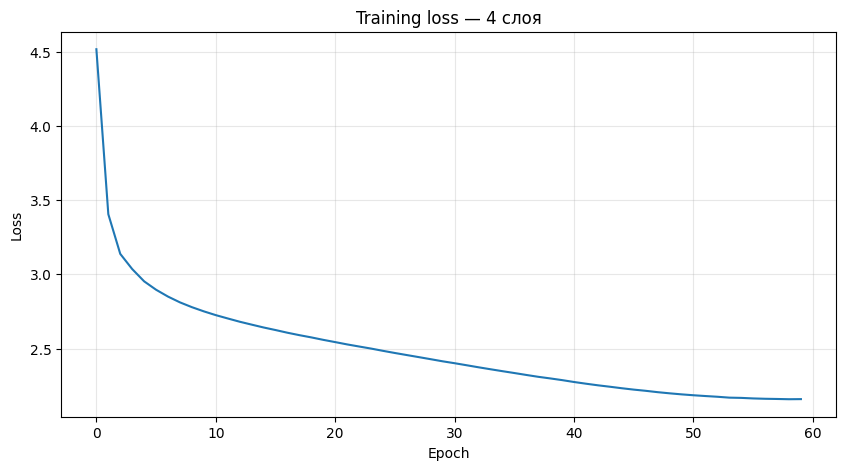

In [ ]:
plt.figure(figsize=(10, 5))
plt.plot(hist_big['loss'])
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training loss — 4 слоя')
plt.grid(True, alpha=0.3)
plt.show()

## тест

In [ ]:
ck = torch.load(f'{checkpoint_dir}/transformer_big_best.pt', map_location=device, weights_only=False)
model_big.load_state_dict(ck['model_state_dict'])
eval_df = seq_df.sample(n=1000, random_state=42)
results_big = compute_metrics(model_big, eval_df, trie, k_list=[5, 10, 50, 100], device=device)
print('эпоха', ck['epoch'], results_big)

эпоха 30 {'Recall@5': np.float64(0.049), 'NDCG@5': np.float64(0.03515880386939717), 'Recall@10': np.float64(0.064), 'NDCG@10': np.float64(0.040140948927783776), 'Recall@50': np.float64(0.156), 'NDCG@50': np.float64(0.0597773676353401), 'Recall@100': np.float64(0.208), 'NDCG@100': np.float64(0.06828264075152657)}


In [ ]:
def level_hits(model, df):
    model.eval()
    ranks = [[], [], []]
    with torch.no_grad():
        for _, row in df.iterrows():
            history = prepare_history_for_generation(row['test_hist_semantic'], MAX_SEQ_LEN, num_levels=3, reserve=3)
            true_codes = [int(c) for c in semantic_ids[row['test']]]
            for level in range(3):
                prefix = true_codes[:level]
                valid = trie.valid_next_codes(prefix)
                seq = history + prefix
                logits = get_logits_at_position(model, seq, len(seq) - 1, device)
                ranks[level].append((logits[valid] > logits[true_codes[level]]).sum().item() + 1)
    for level in range(3):
        r = np.array(ranks[level])
        print(f"уровень {level}: топ-1 {np.mean(r == 1) * 100:.1f}% | топ-10 {np.mean(r <= 10) * 100:.1f}% | средний ранг {r.mean():.2f}")

print('основная модель (2 слоя, эпоха 50):')
level_hits(model, eval_df)
print('\nглубокая модель (4 слоя, эпоха', ck['epoch'], '):')
level_hits(model_big, eval_df)

основная модель (2 слоя, эпоха 50):
уровень 0: топ-1 4.1% | топ-10 27.0% | средний ранг 59.18
уровень 1: топ-1 18.8% | топ-10 59.3% | средний ранг 14.68
уровень 2: топ-1 81.8% | топ-10 99.8% | средний ранг 1.29

глубокая модель (4 слоя, эпоха 30 ):
уровень 0: топ-1 6.0% | топ-10 27.6% | средний ранг 55.02
уровень 1: топ-1 20.4% | топ-10 64.2% | средний ранг 13.20
уровень 2: топ-1 83.2% | топ-10 100.0% | средний ранг 1.27
